# Mini Projet – Contrôle qualité composants PCB

$$Omar \, Fathi \> \& \> Léo \, Cazenave$$

**Dataset 1** , 15 000 composants , 8 variables quantitatives , 5 qualitatives

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.preprocessing import LabelEncoder

df = pd.read_excel('pcb_dataset_1.xlsx')
for col in ['component_type','production_line','supplier','defect','defect_type']:
    df[col] = df[col].astype('category')

var_quant = ['resistance_ohm','capacitance_uF','temperature_test_C',
             'voltage_drop_V','current_leak_mA','signal_noise_dB',
             'power_consumption_W','response_time_ms']

print(f"Dimensions : {df.shape[0]} observations, {df.shape[1]} variables")
print(f"Taux de défauts : {(df['defect']=='FAIL').mean()*100}%")
print(df[var_quant].describe().round(2))


Dimensions : 15000 observations, 14 variables
Taux de défauts : 48.14%
       resistance_ohm  capacitance_uF  temperature_test_C  voltage_drop_V  \
count        15000.00        15000.00            15000.00        15000.00   
mean           422.68           68.98               44.95            3.51   
std            453.08          103.68                2.97            0.26   
min              2.51            0.16               33.78            2.87   
25%              5.90            0.56               42.96            3.31   
50%            192.86            7.80               44.94            3.44   
75%            909.92          171.21               46.92            3.71   
max           1703.40          462.37               56.45            4.37   

       current_leak_mA  signal_noise_dB  power_consumption_W  response_time_ms  
count         15000.00         15000.00             15000.00          15000.00  
mean              0.48            17.22                 1.12             

Le jeu de données contient 15 000 composants décrits par 8 variables quantitatives (résistance, capacitance, température, chute de tension, courant de fuite, rapport signal/bruit, consommation et temps de réponse) et 5 variables qualitatives (type de composant, ligne de production, fournisseur, statut défaut et type de défaut).

Le taux de défauts est d'environ 48 %, ce qui signifie que les classes OK et FAIL sont relativement équilibrées.
Ce taux est  élevé pour un processus industriel mais bon pour l'ADL.
Les écarts-types sont très élevés pour la résistance et la capacitance

In [7]:
print("\nValeurs manquantes")
print(df.isnull().sum())


Valeurs manquantes
component_id              0
component_type            0
production_line           0
supplier                  0
resistance_ohm            0
capacitance_uF            0
temperature_test_C        0
voltage_drop_V            0
current_leak_mA           0
signal_noise_dB           0
power_consumption_W       0
response_time_ms          0
defect                    0
defect_type            7779
dtype: int64


La valeure de la variable `defect_type` est encodée en la chaîne `"None"` dans le jeu de données d’origine pour les individus n’ayant pas de défaut, ce qui est interprété comme l’objet `None` de Python une fois parsé dans un `DataFrame`. On retrouve d’ailleurs la valeur de `48.14%` de défauts, avec ce nombre de `None`tirmocmoc

On peut donc ignorer cette valeur dans le comptage des valeurs manquantes et conclure que le jeu de données n’a aucun individu invalide.

# Distribution des variables qualitatives - diagrammes en secteurs

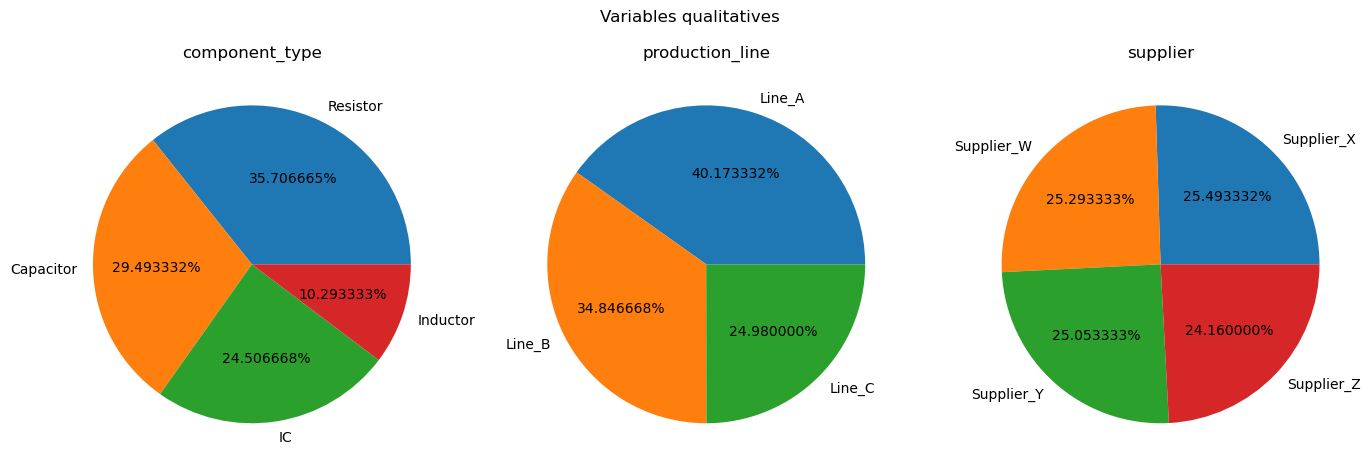

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
for ax, col in zip(axes, ['component_type', 'production_line', 'supplier']):
    counts = df[col].value_counts()
    ax.pie(counts, labels=counts.index, autopct='%1f%%')
    ax.set_title(col)
plt.suptitle("Variables qualitatives")
plt.tight_layout()
plt.show()

Les 4 fournisseurs sont bien équilibrés pas de biais de sous-représentation

## 1. Analyse univariée par statut (OK/FAIL)

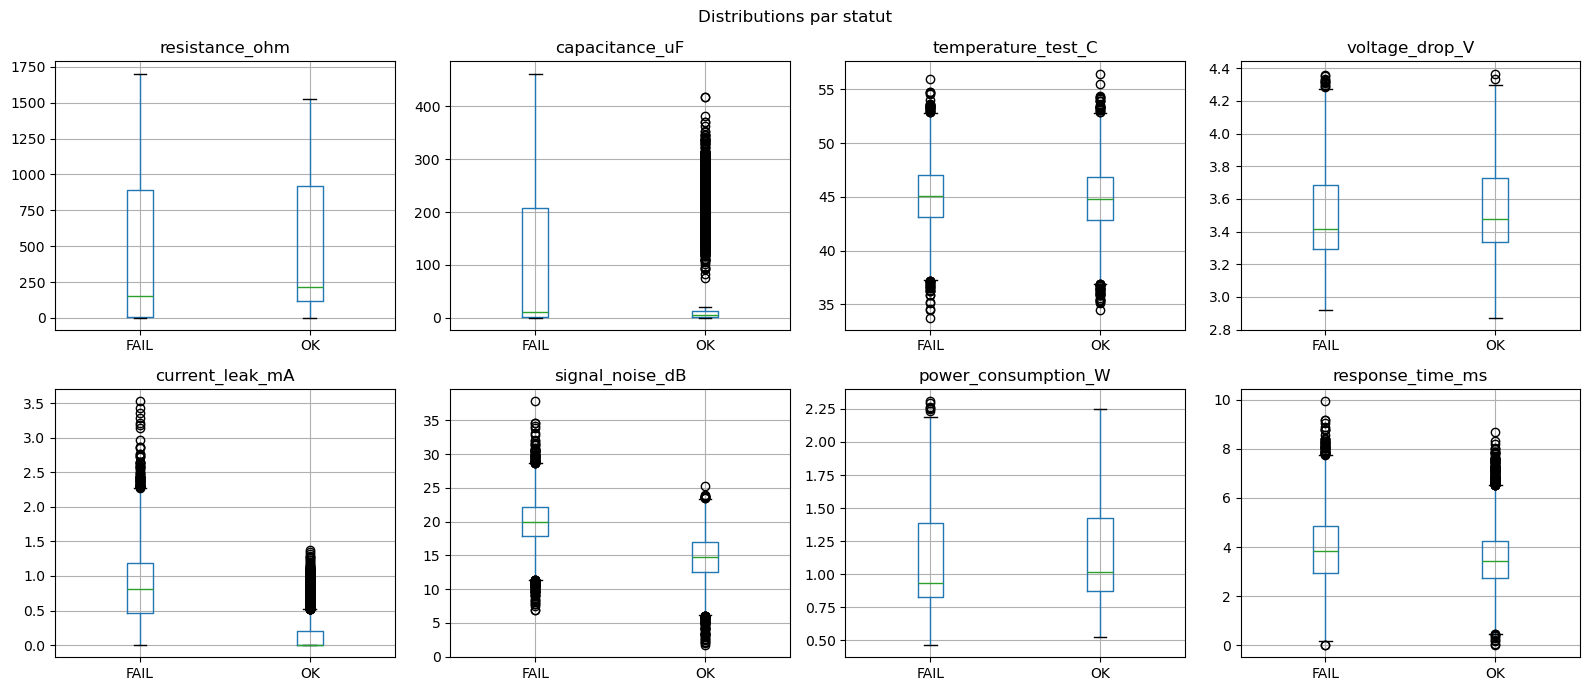

        resistance_ohm  capacitance_uF  temperature_test_C  voltage_drop_V  \
defect                                                                       
FAIL        377.885451       94.449806           45.076062        3.491999   
OK          464.268382       45.336507           44.836515        3.528534   

        current_leak_mA  signal_noise_dB  power_consumption_W  \
defect                                                          
FAIL           0.841914        19.997962             1.090004   
OK             0.135575        14.649432             1.140347   

        response_time_ms  
defect                    
FAIL            3.969740  
OK              3.545854  


In [16]:
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for ax, col in zip(axes.flatten(), var_quant):
    df.boxplot(column=col, by='defect', ax=ax)
    ax.set_title(col); ax.set_xlabel('')
plt.suptitle("Distributions par statut")
plt.tight_layout()
plt.show()

print(df.groupby('defect', observed=False)[var_quant].mean().round(3))


Les boxplots de la distrubution par statut montrent que les variables `current_leak_mA` et `signal_noise_dB` présentent les différences les plus visibles entre les composants OK et FAIL : les pièces défectueuses ont en moyenne un courant de fuite et un bruit plus élevés.

Pour les autres variables (résistance, capacitance, température, etc.), les distributions se chevauchent fortement entre OK et FAIL, ce qui suggère qu'elles ne sont pas à elles seules de bons indicateurs de défaut.

Les autres botploxs (distubitions par component_type et supplier) sont quasi identiques entre Line_A, Line_B, Line_C , pareil pour le fournisseur.
La ligne de production et le fournisseur ne différencient pas les mesures physiques, donc on enlève ces botploxs inutiles pour notre étude

**Conclusion :** Le courant de fuite et le rapport signal/bruit sont les deux paramètres les plus liées à l'apparition de défauts

## 2. Matrice de corrélations

<Figure size 2127.74x2000 with 72 Axes>

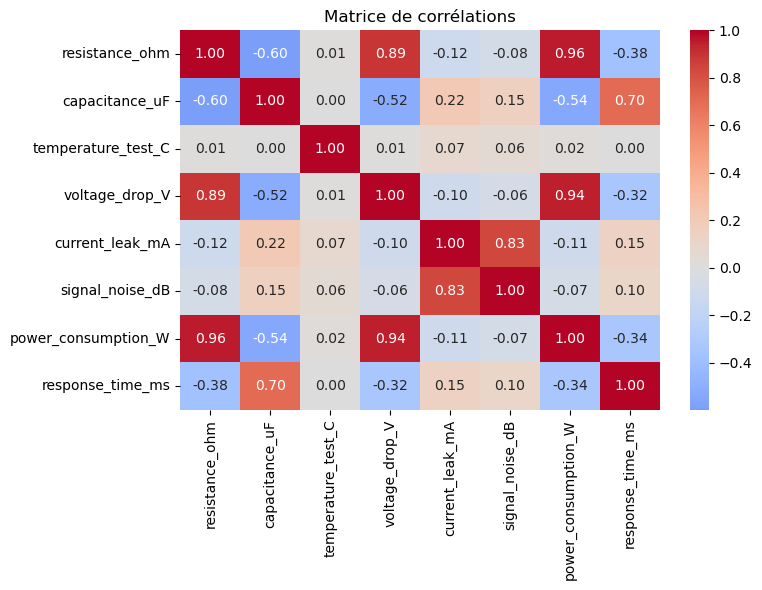

In [19]:
# Scatter Matrix
sns.pairplot(df, hue="component_type")
plt.title("Analiyse bivariée regroupée par type de composant")
plt.tight_layout()
plt.show()

# Matrice de corrélations
C = df[var_quant].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(C, annot=True, cmap='coolwarm', center=0)
plt.title("Matrice de corrélations")
plt.tight_layout()
plt.show()


On observe des corrélations fortes entre :

- `resistance_ohm`, `voltage_drop_V` et `power_consumption_W`, qui évoluent ensemble selon la loi d'Ohm ;
- `response_time_ms` et `capacitance_uF`sont liés par la constante de temps RC ;
- `current_leak_mA` et `signal_noise_dB`, dû au fait que le bruit dans un composant soit proportionnel au courant qui le traverse (ces variables sont d’ailleurs très peu corrélées aux autres variables) ;

**Conclusion :** Il y a de la redondance entre certaines variables (résistance / tension / puissance et capacitence / temps de réponse). L'ACP permettra de résumer cette information. Les variables `current_leak` et `signal_noise` apportent une information distincte importante. La température du composant semble ne pas apporter d’information utile.

## 3. ACP centrée-réduite

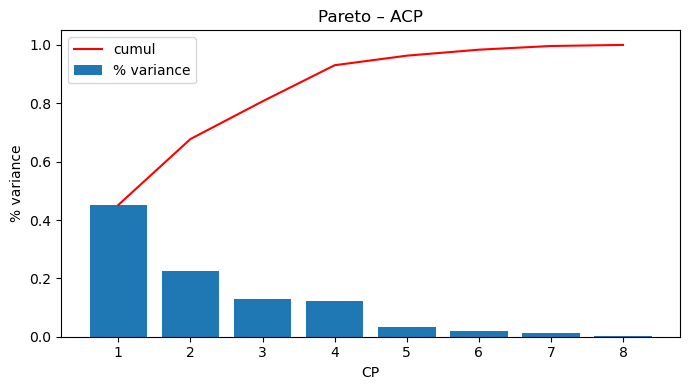

% variance : [45.17279288 22.57462685 12.92647273 12.36954386  3.27109484  2.05255752
  1.26710255  0.36580877]
Cumul      : [ 45.17279288  67.74741973  80.67389246  93.04343632  96.31453116
  98.36708868  99.63419123 100.        ]


In [11]:
X_cr = (df[var_quant] - df[var_quant].mean()) / df[var_quant].std()
acp  = PCA()
Xacp = acp.fit_transform(X_cr)
pq   = len(var_quant)

# Pareto
plt.figure(figsize=(7, 4))
plt.bar(range(1, pq+1), acp.explained_variance_ratio_, label='% variance')
plt.plot(range(1, pq+1), np.cumsum(acp.explained_variance_ratio_), color='red', label='cumul')
plt.xlabel("CP");
plt.ylabel("% variance")
plt.title("Pareto ACP");
plt.legend()
plt.tight_layout();
plt.show()
print("% variance :", (acp.explained_variance_ratio_*100))
print("Cumul      :", (np.cumsum(acp.explained_variance_ratio_)*100))


La première composante principale (CP1) explique 45.2% de la variance et la deuxième 22.6%. Avec les 2 premiers axes on atteint 67.7% de la variance totale et il faut 4 axes pour dépasser 90%.
L'ACP ne réduit donc pas très efficacement la dimension à 2 ,les 8 variables portent des informations relativement variees,cohérent avec la faible corrélation entre certaines valeurs

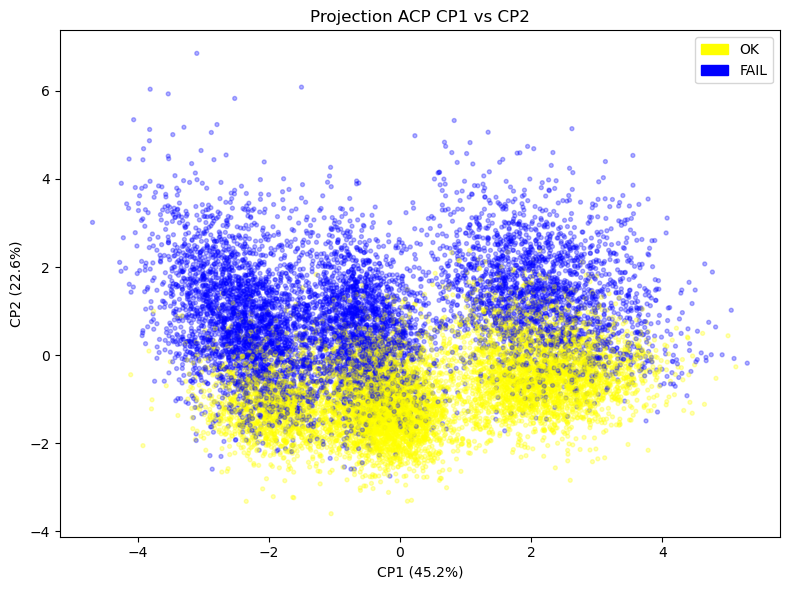

In [12]:
# Projection CP1/CP2 colorée OK/FAIL
colors = df['defect'].map({'OK':'yellow','FAIL':'blue'})
plt.figure(figsize=(8, 6))
plt.scatter(Xacp[:,0], Xacp[:,1], c=colors, alpha=0.3, s=8)
plt.xlabel(f"CP1 ({acp.explained_variance_ratio_[0]*100}%)")
plt.ylabel(f"CP2 ({acp.explained_variance_ratio_[1]*100}%)")
plt.title("Projection ACP CP1 vs CP2")
from matplotlib.patches import Patch
plt.legend(handles=[Patch(color='yellow',label='OK'), Patch(color='blue',label='FAIL')])
plt.tight_layout(); plt.show()


Sur la projection CP1/CP2, les points OK et FAIL se chevauchent largement. L'ACP ne permet pas de séparer visuellement les deux classes.
Il faut passer à l'ADL

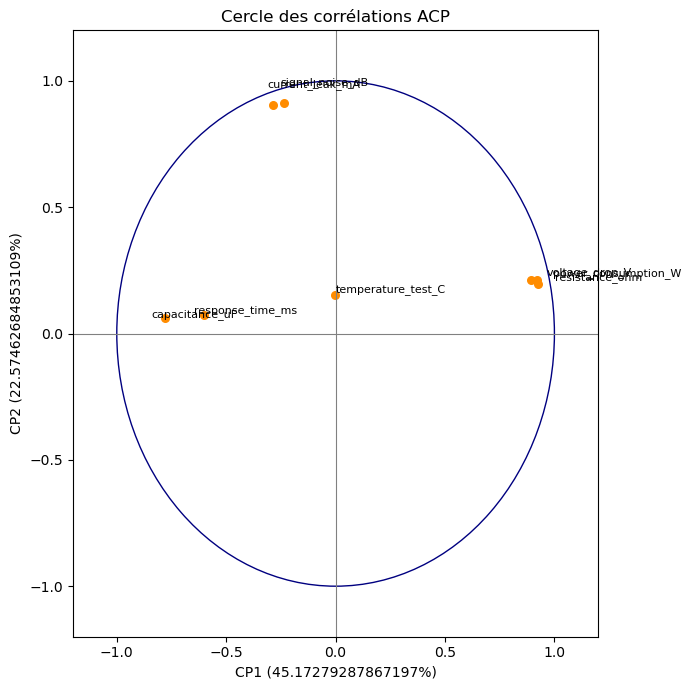

In [13]:

# Cercle des corrélations ACP
corr_cp = np.array([[np.corrcoef(Xacp[:,i], df[var_quant].iloc[:,j])[0,1]
                     for j in range(pq)] for i in range(pq)])

fig, ax = plt.subplots(figsize=(10,10))
ax.add_patch(plt.Circle((0,0), 1, fill=False, color='blue'))
ax.axhline(0);
ax.axvline(0)
for j, v in enumerate(var_quant):
    ax.scatter(corr_cp[0,j], corr_cp[1,j], color='orange')
    ax.text(corr_cp[0,j], corr_cp[1,j], v, fontsize=8)
ax.set_xlim(-1.2,1.2); 
ax.set_ylim(-1.2,1.2)
ax.set_xlabel(f"CP1 ({acp.explained_variance_ratio_[0]*100}%)")
ax.set_ylabel(f"CP2 ({acp.explained_variance_ratio_[1]*100}%)")
ax.set_title("Cercle des corrélations ACP")
plt.tight_layout();
plt.show()



Le cercle des corrélations confirme :
**CP1** est fortement corrélée à `resistance_ohm` (0.93), `power_consumption_W` (0.92), `voltage_drop_V` (0.90) d'un côté, et `capacitance_uF` (−0.78), `response_time_ms` (−0.60) de l'autre. Cet axe représente les caractéristiques électriques globales du composant.
**CP2** est dominée par `current_leak_mA` et `signal_noise_dB` . Cet axe capture les indicateurs de qualité / bruit.

**Conclusion :** L'axe CP2 porte justement les variables les plus liées aux défauts (courant de fuite, bruit), mais il n'explique que 22.6% de la variance totale

## 4. ADL – OK vs FAIL

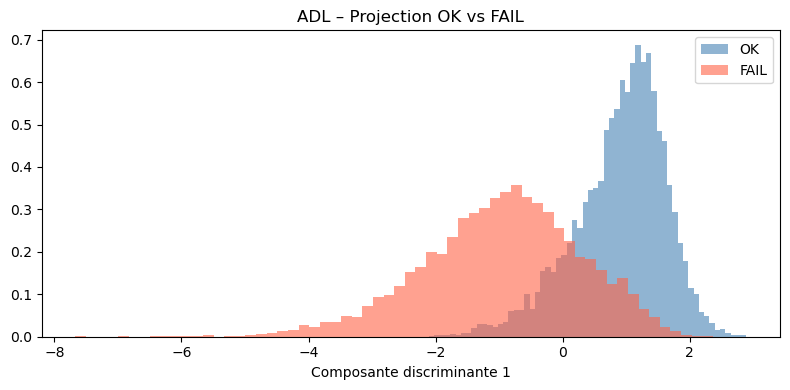

In [14]:
lda  = LinearDiscriminantAnalysis()
Xlda = lda.fit_transform(df[var_quant], df['defect'])

# Distribution sur l'axe discriminant
fig, ax = plt.subplots(figsize=(8, 4))
for status, color in [('OK','yellow'), ('FAIL','blue')]:
    idx = df['defect'] == status
    ax.hist(Xlda[idx,0], bins=60, alpha=0.6, color=color, label=status, density=True)
ax.set_xlabel("Composante discriminante 1")
ax.set_title("ADL – Projection OK vs FAIL")
ax.legend(); plt.tight_layout(); plt.show()



L'ADL produit un seul axe discriminant (2 classes, 2−1 = 1 axe).L'histogramme montre une bonne séparation entre les distributions OK et FAIL sur cet axe.
Les corrélations avec CD1 montrent que :
`current_leak_mA` et `signal_noise_dB`  sont les variables les plus discriminantes
Les autres variables (résistance, capacitance, température, etc.) contribuent faiblement à la descrimination

**Conclusion :** Pour détecter les defauts, il suffit principalement de voirle courant de fuite et le rapport signal/bruit.Un composant avec un courant de fuite élevé et un bruit important a une forte probabilité d'être défectueux.

## 5. ADL – Par type de défaut

Effectifs : defect_type
Solder_Issue     4036
Short_Circuit    3117
Open_Circuit       68
Name: count, dtype: int64
Variance expliquée : [97.45341715  2.54658285] %


/tmp/nix-shell.i9OTKE/ipykernel_15585/3959891640.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  centres     = df_fail.groupby('defect_type')[var_quant].mean()


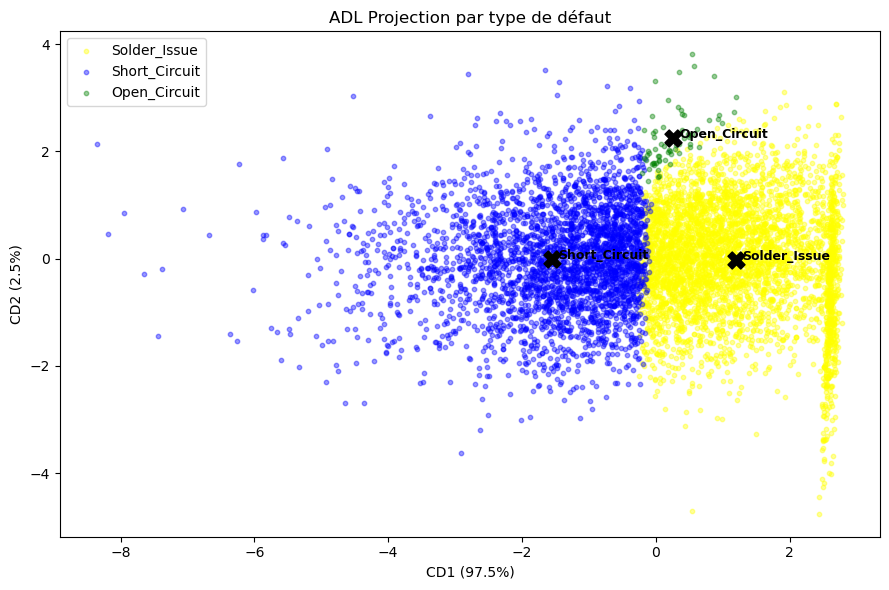

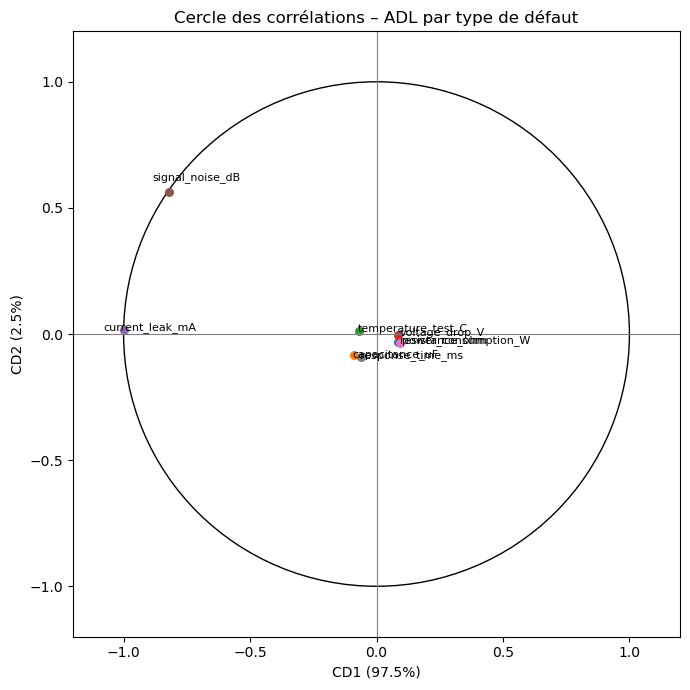

                          CD1       CD2
resistance_ohm       0.084554 -0.031775
capacitance_uF      -0.087354 -0.083462
temperature_test_C  -0.068953  0.010148
voltage_drop_V       0.083962 -0.005457
current_leak_mA     -0.999372  0.014714
signal_noise_dB     -0.821874  0.563823
power_consumption_W  0.093692 -0.034053
response_time_ms    -0.061852 -0.090098


In [15]:
df_fail = df[df['defect']=='FAIL'].dropna(subset=['defect_type']).copy()
print("Effectifs :", df_fail['defect_type'].value_counts())

lda2  = LinearDiscriminantAnalysis()
Xlda2 = lda2.fit_transform(df_fail[var_quant], df_fail['defect_type'])
print("Variance expliquée :", (lda2.explained_variance_ratio_*100), "%")

palette = {'Solder_Issue':'yellow','Short_Circuit':'blue','Open_Circuit':'green'}
plt.figure(figsize=(9, 6))
for dt, color in palette.items():
    idx = df_fail['defect_type'] == dt
    plt.scatter(Xlda2[idx,0], Xlda2[idx,1], c=color, alpha=0.4, s=10, label=dt)

centres     = df_fail.groupby('defect_type', observed=False)[var_quant].mean()
centres_lda = lda2.transform(centres)
for i, dt in enumerate(centres.index):
    plt.scatter(centres_lda[i,0], centres_lda[i,1], c='black', marker='X', zorder=5)
    plt.text(centres_lda[i,0], centres_lda[i,1], dt, fontsize=9, fontweight='bold')
plt.xlabel(f"CD1 ({lda2.explained_variance_ratio_[0]*100}%)")
plt.ylabel(f"CD2 ({lda2.explained_variance_ratio_[1]*100}%)")
plt.title("ADL Projection par type de défaut")
plt.legend(); plt.tight_layout(); plt.show()

# Cercle des corrélations
corr2 = pd.DataFrame(
    {f"CD{i+1}": [np.corrcoef(df_fail[v].values, Xlda2[:,i])[0,1] for v in var_quant]
     for i in range(2)}, index=var_quant)

fig, ax = plt.subplots(figsize=(7, 7))
ax.add_patch(plt.Circle((0,0),1,fill=False))
ax.axhline(0)
ax.axvline(0)
for v in var_quant:
    ax.scatter(corr2.loc[v,'CD1'], corr2.loc[v,'CD2'])
    ax.text(corr2.loc[v,'CD1'], corr2.loc[v,'CD2'], v, fontsize=8)
ax.set_xlim(-1.2,1.2);
ax.set_ylim(-1.2,1.2)
ax.set_xlabel(f"CD1 ({lda2.explained_variance_ratio_[0]*100}%)")
ax.set_ylabel(f"CD2 ({lda2.explained_variance_ratio_[1]*100}%)")
ax.set_title("Cercle des corrélations ADL par type de défaut")
plt.tight_layout();
plt.show()
print(corr2)


Parmi les pièces défectueuses, on distingue 3 types : Solder_Issue (4 036), Short_Circuit (3 117) et Open_Circuit (68, très rare).

L'ADL à 3 classes donne 2 axes discriminants. Le premier axe (CD1) explique **97.5 %** du pouvoir discriminant et est quasi-exclusivement lié à `current_leak_mA` (r = −0.999) et `signal_noise_dB` (r = −0.82). Le second axe (CD2, 2.5 %) est surtout lié à `signal_noise_dB` (r = 0.56).

Sur la projection, les Solder_Issue et Short_Circuit se séparent selon CD1, tandis que les Open_Circuit (très peu nombreux) se distinguent légèrement sur CD2.

**Conclusion :** Le courant de fuite est le critère principal qui distingue les types de défaut : les courts-circuits présentent un courant de fuite nettement plus élevé que les problèmes de soudure. Le bruit aide à affiner la distinction. Les circuits ouverts sont trop rares pour tirer des conclusions fiables.

## Conclusion générale – Dataset 1

L'analyse du jeu de données de 15 000 composants PCB permet de tirer les conclusions suivantes :

1. **Variables clés :** Le courant de fuite (`current_leak_mA`) et le rapport signal/bruit (`signal_noise_dB`) sont les deux variables les plus discriminantes pour identifier les composants défectueux.Les autres variables éléctriques (résistance, tension, puissance) sont fortement corrélées entre elles mais peu utiles pour la détection de defauts.

2. **ACP et ADL :** L'ACP a permis de comprendre la structure des données (groupes de variables corrélées) mais ne sépare pas les classes OK/FAIL. L'ADL, en revanche, fournit une séparation efficace 

3. **types de défauts :** L'ADL sur les pieces FAIL distingue bien les Solder_Issue des Short_Circuit, principalement via le courant de fuite. Les Open_Circuit sont trop rares (68 sur 7 221) pour être analysés de façon fiable

4. **Recommandation industrielle :** Pour le contrôle qualité, un seuil sur le courant de fuite et le bruit permettrait de détecter la majorité des défauts sans avoir besoin de toutes les mesures électriques.
